<div align="right">
  <img src="images/utn.png" width="400" />
</div>
<br>

# Diseño de filtro mediante Aproximación de Chebyshev
## Teoría de Circuitos II

<br>

### **Autor:** <font size="5">Guido Cucciniello</font>
### **Docentes:** <font size="4">Mariano Llamedo Soria - David Moharos</font>
### **Institución:** <font size="4">Universidad Tecnológica Nacional (UTN FRBA)</font>

Se parte de la siguiente plantilla de requerimientos
<figure style="text-align: center;">     
    <img src="images/plantilla.png" alt="Descripción de la imagen" style="width: 70%;">
    <figcaption>Figura 1: Plantilla de requerimientos del filtro objetivo.</figcaption>
</figure>

Dados los requerimientos necesarios, es observable que se exige un alto nivel de atenuación $\alpha_{\text{min}}$ para frecuencias bajas y un nivel de atenuación máximo $\alpha_{\text{max}}$ para frecuencias altas, por lo tanto se puede concluir que el diseño que se propone corresponde a un filtro pasa altos. Se podrá implementar la aproximación de Chebyshev para diseñar el filtro con los requerimientos dados únicamente si se trabaja con un prototipo pasa bajos. Para eso, se lleva a cabo la siguiente transformación de dominio $$\Omega'(\omega') = \frac{1}{\omega'}$$ donde nuestro dominio transformado (dom. pasa bajos normalizado) es el recíproco del dominio origen (dom. pasa altos normalizado). Gráficamente la transformación se ve como
<figure style="text-align: center;">     
    <img src="images/plantilla_t1.png" alt="Descripción de la imagen" style="width: 70%;">
    <figcaption>Figura 2: Transformación del dominio pasa altos a pasa bajos.</figcaption>
</figure>

Una vez llevada a cabo esta transformación, se podrá aproximar una función transferencia cuya magnitud al cuadrado responda a este estilo $$|T_n(j\Omega)|^{2} = \frac{1}{1 + \varepsilon^{2}\,C_n^{2}(\Omega)}$$
donde los valores del factor de ripple $\varepsilon$ y el orden del $n$ del filtro, nos permitirán definir perfectamente la transferencia para ser aproximada mediante los polinomios de Chebyshev $C_n(\Omega)$.

## Cálculo del factor de Ripple
Es el factor que determiná cual será la amplitud máxima que tendrán las oscilaciones dentro de la banda de paso de la respuesta en frecuencia
\begin{align*}
    \varepsilon^{2} &= 10^{\frac{\alpha_{\text{max}}}{10}} - 1 \\\\
    \varepsilon^{2} &= 0.1220
\end{align*}

## Cálculo del Orden del filtro
La atenuación en la banda detenida (a partir de $\Omega_s' = \frac{1}{\frac{\omega_s}{\omega_p}} = 3.9949)$ para una aproximación de Chebyshev se calcula mediante 
$$\alpha_n = 10\log\left[ 1 + \varepsilon^{2}\cosh^{2}\left( n\,\text{arcosh}\left(\Omega_s'\right)\right)\right]$$
Iterando esta expresión para distintos valores de $n$ se podrá observar cual es el orden del filtro necesario para alcanzar la atenuación mínima exigida en la plantilla.
\begin{align*}
    n &= 1: & \alpha &= 4.6966 \,\text{dB} \Rightarrow \alpha < \alpha_{\text{min}}\\\\
    n &= 2: & \alpha &= 20.7136 \,\text{dB} \Rightarrow \alpha < \alpha_{\text{min}} \\\\
    n &= 3: & \alpha &= 38.5906 \,\text{dB} \Rightarrow \alpha \geq \alpha_{\text{min}}
\end{align*}
Por lo tanto, el orden del filtro que garantinza una atenuación mayor o igual a $30\,\text{dB}$ en la banda detenida es $n = 3$

## Cálculo de los polos
Partiendo de que $$|T_n(j\Omega)|^{2}\Big|_{\Omega = \frac{S}{j}} = T(S)\,T(-S) =  \frac{1}{1 + \varepsilon^{2}\,C_n^{2}(\frac{S}{j})}$$
y haciendo el correspondiente análisis de las singularidades de está función transferencia en el dominio $S$, se puede concluir que los polos $$S_k = \sigma_k + j\,\omega_k \quad con \quad k={0,1,...,2n-1}$$ se podrán ubicar en el plano complejo calculando los siguientes parámetros 
\begin{align*}
    \sigma_k &= \sin(\theta_k)\,\sinh(a) \\\\
    \omega_k &= \cos(\theta_k)\,\cosh(a) \\\\
    \theta_k &= \frac{(2k+1)\,\pi}{2n} \\\\
    a &= \frac{\text{arcsinh}(\frac{1}{\varepsilon})}{n}
\end{align*}

Polos los cuales se ubicarán en el lugar geométrico de una Elipse que responde a $$\left(\frac{\sigma}{\sinh(a)}\right)^{2} + \left(\frac{\omega}{\cosh(a)}\right)^{2} = 1$$

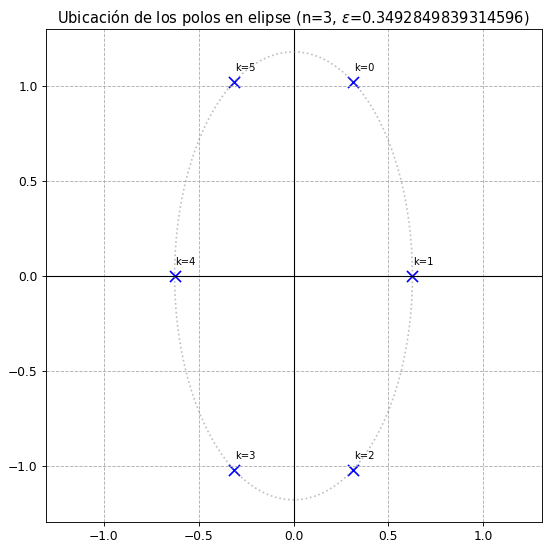

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del filtro
n = 3
epsilon = np.sqrt(0.1220)
k_values = np.arange(2 * n)

# Cálculo del parámetro 'a'
a = np.arcsinh(1 / epsilon) / n

# Cálculo de theta_k
theta = ((2 * k_values + 1) * np.pi) / (2 * n)

# Cálculo de la parte real (sigma) e imaginaria (omega)
sigma = np.sin(theta) * np.sinh(a)
omega = np.cos(theta) * np.cosh(a)

polos = sigma + 1j * omega

plt.figure(figsize=(8, 8))
plt.scatter(np.real(polos), np.imag(polos), marker='x', color='blue', s=100)

# Etiquetas para cada k
for i, k in enumerate(k_values):
    plt.annotate(f'k={k}', 
                 (np.real(polos[i]), np.imag(polos[i])),
                 textcoords="offset points", 
                 xytext=(10, 10),             
                 ha='center',                
                 fontsize=9)

plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.grid(True, which='both', linestyle='--')
plt.title(f'Ubicación de los polos en elipse (n={n}, $\\varepsilon$={epsilon})')
plt.axis('equal')

# Semieje horizontal = sinh(a), Semieje vertical = cosh(a)
t = np.linspace(0, 2 * np.pi, 100)
x_elipse = np.sinh(a) * np.cos(t)
y_elipse = np.cosh(a) * np.sin(t)
plt.plot(x_elipse, y_elipse, color='gray', linestyle=':', alpha=0.5)

plt.show()

Los polos que garantizan la estabilidad del filtro corresponden a los valores de $k=3, \quad k=4 \quad \text{y} \quad k=5$. 
\begin{align*}
    S_{3,5} &= -0.3133 \pm j\,1.0219 \\\\
    S_{4} &= -0.6265 
\end{align*}
Descarto el resto de polos, de lo contrario la estabilidad del sistema estará gravemente afectada.

Por cada polo real se corresponde una sección de primer orden cuya transferencia pasa bajos canónica responde a
$$T_{\text{1er Orden}}(S) = \frac{\omega_{0_k}}{S + \omega_{0_k}}$$
Por cada par de polos complejos conjugados se corresponde una sección de segundo orden cuya transferencia pasa bajos canónica responde a $$T_{\text{2do Orden}}(S) = \frac{\omega_{0_k}^{2}}{S² + S\,\frac{\omega_{0_k}}{Q_k} + \omega_{0_k}^{2}}$$
donde 
\begin{align*}
    \omega_{0_k}^{2} &= \sigma_k^{2} + \omega_k^{2} \\\\
    Q_k &= \frac{\omega_{0_k}}{2\,\sigma_k} = \frac{1}{2\cos(\arctan(\frac{\omega_k}{\sigma_k}))}
\end{align*}
Entonces, la sección de primer orden y segundo orden son
\begin{align*}
     T_1(S) &= \frac{0.6265}{S + 0.6265}  \\\\
     T_2(S) &= \frac{1.1424}{S² + S\,0.6266 + 1.1424}
\end{align*}
Componiendo la transferencia pasa bajos prototipo, tenemos
\begin{align*}
    T_{\text{LP}_3}(S) &= T_1(S) \cdot T_2(S) \\\\
    T_{\text{LP}_3}(S) &= \frac{0.6265}{S + 0.6265} \cdot \frac{1.1424}{S² + S\,0.6266 + 1.1424}
\end{align*}
Para volver al dominio pasa altos normalizado, aplicamos la misma transformación $$T_{\text{HP}}(s') = T_{\text{LP}}(S) \Big|_{S = \frac{1}{s'}}$$
Haciendo el álgebra queda que la transferencia pasa altos normalizada es $$T_{\text{HP}}(s') = \frac{s'}{s' + 1.5962} \cdot\frac{s'^{2}}{s'^{2} + s'\,0.5485 + 0.8753}$$
Para desnormalizar la transferencia, simplemente
$$T_{\text{HP}}(s) \Big|_{s = s'\,\omega_p} = \frac{s}{s + 400646.2} \cdot \frac{s^{2}}{s^{2} + s\,137673.5 + 55144775300}$$

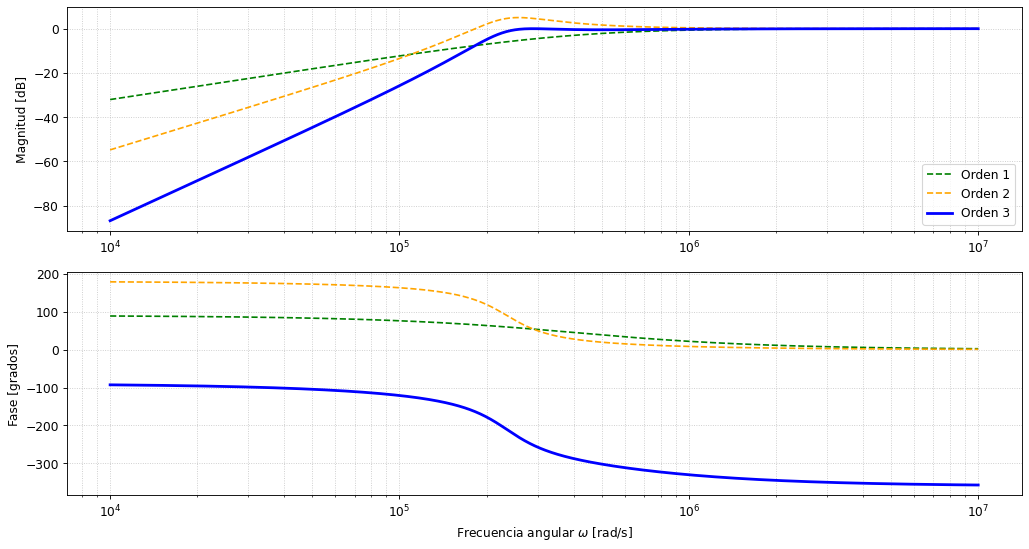

In [29]:
 # Inicialización e importación de módulos

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sig

fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi
fig_font_size = 11

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

from pytc2.sistemas_lineales import pretty_print_lti
from pytc2.general import print_subtitle

# --- Transferencias ---

# --- Etapa de Orden 1: s / (s + 400646.2) ---
num_1 = [1, 0]
den_1 = [1, 400646.2]
sys_1 = sig.TransferFunction(num_1, den_1)

#--- Etapa de Orden 2: s^2 / (s^2 + s*137673.5 + 55144775300) ---
num_2 = [1, 0, 0]
den_2 = [1, 137673.5, 55144775300]
sys_2 = sig.TransferFunction(num_2, den_2)


# --- Sistema Total (Orden 3) ---
num_tot = [1, 0, 0, 0]
den_tot = np.convolve(den_1, den_2)
sys_tot = sig.TransferFunction(num_tot, den_tot)

# Rango de frecuencias para la evaluación
w_eval = np.logspace(4, 7, 1000)

# Calculamos la respuesta de cada etapa
w, mag1, phase1 = sig.bode(sys_1, w_eval)
w, mag2, phase2 = sig.bode(sys_2, w_eval)
w, mag_tot, phase_tot = sig.bode(sys_tot, w_eval)

fig, (ax1, ax2) = plt.subplots(2, 1)

# --- Gráfico de Magnitud ---
ax1.semilogx(w, mag1, color='green', linestyle='--', lw=1.5, label='Orden 1')
ax1.semilogx(w, mag2, color='orange', linestyle='--', lw=1.5, label='Orden 2')
ax1.semilogx(w, mag_tot, color='blue', linestyle='-', lw=2.5, label='Orden 3')
ax1.set_ylabel('Magnitud [dB]')
ax1.grid(True, which='both', linestyle=':', alpha=0.7)
ax1.legend(loc='lower right')

# --- Gráfico de Fase ---

ax2.semilogx(w, phase1, color='green', linestyle='--', lw=1.5)
ax2.semilogx(w, phase2, color='orange', linestyle='--', lw=1.5)
ax2.semilogx(w, phase_tot, color='blue', linestyle='-', lw=2.5)
ax2.set_xlabel('Frecuencia angular $\omega$ [rad/s]')
ax2.set_ylabel('Fase [grados]')
ax2.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show() 

## Comparación del diagrama de polos y ceros

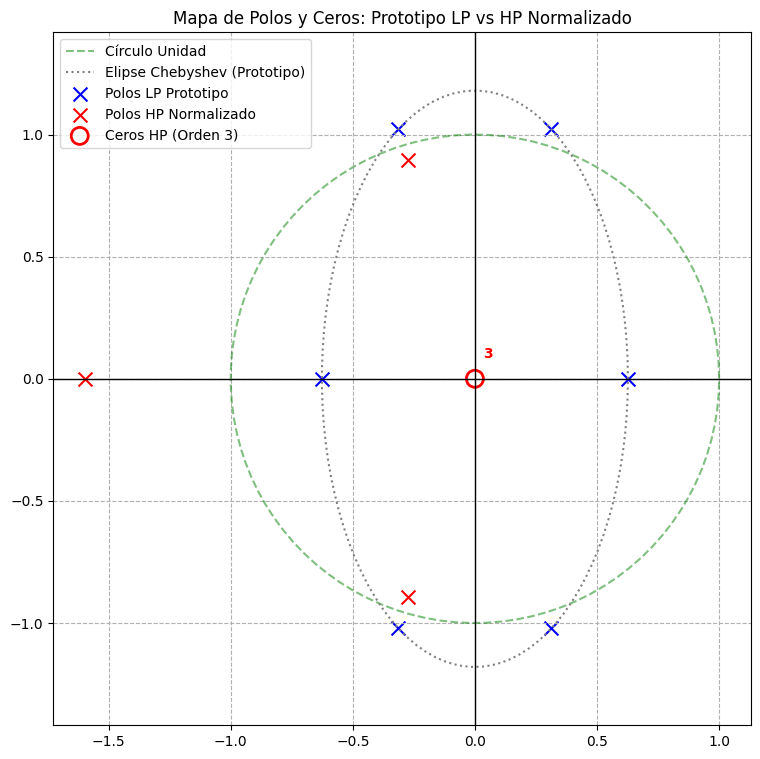

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros del filtro (Chebyshev) ---
n = 3
epsilon = np.sqrt(0.1220)
k_values = np.arange(2 * n)
a = np.arcsinh(1 / epsilon) / n
theta = ((2 * k_values + 1) * np.pi) / (2 * n)

# Polos LP (Prototipo)
sigma = np.sin(theta) * np.sinh(a)
omega = np.cos(theta) * np.cosh(a)
polos_lp = sigma + 1j * omega

# --- Polos HP (Calculados a partir de la transferencia) ---
# s' + 1.5962  y  s'^2 + 0.5485s' + 0.8753
polos_hp = np.concatenate((np.roots([1, 1.5962]), np.roots([1, 0.5485, 0.8753])))

plt.figure(figsize=(9, 9))

# 1. Círculo unidad
t = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(t), np.sin(t), color='green', linestyle='--', alpha=0.5, label='Círculo Unidad')

# 2. Elipse del Prototipo (la que define el filtro)
x_elipse = np.sinh(a) * np.cos(t)
y_elipse = np.cosh(a) * np.sin(t)
plt.plot(x_elipse, y_elipse, color='gray', linestyle=':', label='Elipse Chebyshev (Prototipo)')

# 3. Polos LP (Azul)
plt.scatter(np.real(polos_lp), np.imag(polos_lp), marker='x', color='blue', s=100, label='Polos LP Prototipo')

# 4. Polos HP (Rojo)
plt.scatter(np.real(polos_hp), np.imag(polos_hp), marker='x', color='red', s=100, label='Polos HP Normalizado')

# 5. Ceros HP (Orden 3 en el origen)
plt.scatter(0, 0, marker='o', facecolors='none', edgecolors='red', s=150, linewidths=2, label='Ceros HP (Orden 3)')

# Etiqueta para los ceros
plt.annotate('3', (-0.05, 0), textcoords="offset points", 
             xytext=(15, 15), ha='left', fontsize=10, color='red', weight='bold')

# Estética del gráfico
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.grid(True, which='both', linestyle='--')
plt.title(f'Mapa de Polos y Ceros: Prototipo LP vs HP Normalizado')
plt.axis('equal')
plt.legend(loc='upper left') # Leyenda a la izquierda arriba
plt.show()

Se puede concluir lo siguiente sobre la transformación aplicada

- Ubicación de las singularidades en el plano complejo: Se invierten los ejes principales del lugar geométrico donde están contenidos los polos. Esto trae consigo que la distancia al origen se vea invertida, los polos ubicados inicialmente fuera del circulo de radio unidad una vez aplicada la transformación, quedan dentro de él, y de forma contraria, los que estaban inicialmente dentro del circulo de radio unidad una vez aplicada la transformación quedan fuera de él. 

- Aparición de ceros en el origen: Los ceros del LP están en el infinito, esto implica que tras la transformación hacia HP los ceros estarán en el origen garantizando así el comportamiento típico de un pasa altos, bloquear la continua.
   
- Conservación de la estabilidad: Después de la transformación, los polos se mantienen estrictamente en el semiplano complejo izquierdo, dejando inalterada su estabilidad.

- Conservación del factor de Calidad Q: La disposición angular de cada polo respecto al eje real se mantiene casi inalterada,concluyendo que este valor se conserva

## Implementación con estructuras pasivas
Para poder implementar este filtro de orden 3, basta con configurar una estructura de primer orden seguida de una estructura de segundo orden, ambas conformadas por componentes pasivos.
### Circuito RC (Orden 1)
La configuración de este circuito es la siguiente
<figure style="text-align: center;">     
    <img src="images/rc.png" alt="Descripción de la imagen" style="width: 50%;">
    <figcaption>Figura 3: Filtro RC Pasa Altos.</figcaption>
</figure>
Notar que cuando se opera en un rango de bajas frecuencias, la impedancia del capacitor tiende a tener un comportamiento de circuito abierto, provocando una incidencia nula de bajas frecuencias. En cambio, a frecuencias altas su impedancia tiene un comportamiento de cortocircuito, provocando una gran incidencia de dichas frecuencias. La transferencia del circuito se puede obtener planteando un divisor de tensión y se llega a que $$T_1(s) = \frac{s}{s + \frac{1}{R_1\,C_1}}$$

### Circuito RLC (Orden 2)
<figure style="text-align: center;">     
    <img src="images/RLC1.png" alt="Descripción de la imagen" style="width: 50%;">
    <figcaption>Figura 4: Filtro RLC Pasa Altos.</figcaption>
</figure>
La lógica es la misma: analizando el comportamiento del circuito para bajas y altas frecuencias en términos de impedancias, se llega a una conclusión análoga al circuito de primer orden, con la gran diferencia de que en esta red hay un segundo elemento circuital almacenador de energía, el inductor. Tomando como impedancia equivalente serie la del resistor y el capacitor juntos, se plantea un divisor de tensión junto con la impedancia del inductor y se llega a que $$T_2(s) = \frac{s^{2}}{s^{2} + s\,\frac{R_2}{L} + \frac{1}{L\,C_2}}$$

### Circuito RC + RLC (Orden 3)
Esta es la implementación final, donde cascadeamos las secciones anteriormente presentadas separadas por un elemento activo, el buffer
<figure style="text-align: center;">     
    <img src="images/RC_RLC.png" alt="Descripción de la imagen" style="width: 60%;">
    <figcaption>Figura 5: Filtro Pasa Altos de Orden 3 conformado por FOS + SOS.</figcaption>
</figure>

### Normalización del circuito
Tomaremos como norma de frecuencia general para todo el circuito la pulsación angular de paso $\omega_p$ especificada en la plantilla, es decir $\Omega_\omega = \omega_p\,\left[\frac{\text{rad}}{\text{s}}\right]$

#### Sección de primer orden
Propongo como norma de impedancia $\Omega_Z = R_1\,[\Omega]$, entonces los componentes normalizados se pueden expresar como 
\begin{align*}
     R_1' &= \frac{R_1}{\Omega_Z} = 1 \\\\
     C_1' &= C_1\,\Omega_Z\,\Omega_\omega 
\end{align*}
La pulsación angular de corte normalizada del filtro es $$\omega_{0_1}' = \frac{\omega_{0_1}}{\Omega_\omega} = \frac{\omega_{0_1}}{\omega_p} = \frac{400646.2 \frac{\text{rad}}{\text{s}}}{251000 \frac{\text{rad}}{\text{s}}} = 1.5962$$
Sabiendo que $\omega_{0_1} = \frac{1}{R_1\,C_1} = \frac{1}{R_1'\,\Omega_Z\,\frac{C_1'}{\Omega_Z\,\Omega_\omega}} = \frac{\Omega_\omega}{R_1'\,C_1'} \quad \Rightarrow \quad \omega_{0_1}' = \frac{\omega_{0_1}}{\Omega_\omega} = \frac{1}{R_1'\,C_1'} = 1.5962$

Como $R_1' = 1$, ya que adopté $R_1$ como norma de impedancia, el valor normalizado de capacitancia debe cumplir con el valor de frecuencia normalizada. De este modo, se debe garantizar que $C_1' = 0.6265$

#### Sección de segundo orden
Propongo como norma de impedancia $\Omega_Z = R_2\,[\Omega]$, entonces los componentes normalizados se pueden expresar como 
\begin{align*}
     R_2' &= \frac{R_2}{\Omega_Z} = 1  \\\\
     C_2' &= C_2\,\Omega_Z\,\Omega_\omega \\\\
     L' &= \frac{L\,\Omega_\omega}{\Omega_Z}
\end{align*}
La pulsación angular de corte normalizada del filtro es $$\omega_{0_2}' = \frac{\omega_{0_2}}{\Omega_\omega} = \frac{\omega_{0_2}}{\omega_p} = \frac{\sqrt{55144775300} \frac{\text{rad}}{\text{s}}}{251000 \frac{\text{rad}}{\text{s}}} = 0.9356$$
Sabiendo que $\omega_{0_2} = \frac{1}{\sqrt{L\,C_2}} = \frac{1}{\sqrt{\frac{L'\,\Omega_Z}{\Omega_\omega}\,\frac{C_2'}{\Omega_Z\,\Omega_\omega}}} = \frac{\Omega_\omega}{\sqrt{L'\,C_2'}} \quad \Rightarrow \quad \omega_{0_2}' = \frac{\omega_{0_2}}{\Omega_\omega} = \frac{1}{\sqrt{L'\,C_2'}} = 0.9356$

Simulatáneamente , debemos hallar el valor de $L'$ y $C_2'$ que garantice la frecuencia $\omega_{0_2}'$ y el $Q = 1.7057$ del circuito, obtenido a partir de la transferencia.

Planteamos el sistema de ecuaciones con las condiciones impuestas, teniendo en cuenta que $R_2' = 1$
\begin{equation*}
\left\{
\begin{aligned}
    \frac{1}{L'} &= 0.5485 && \text{(Condición para garantizar el factor } Q\text{)} \\
    \frac{1}{L'\,C_2'} &= 0.8753 && \text{(Condición para garantizar } \omega_{0_2}'\text{)}
\end{aligned}
\right.
\end{equation*}

Despejando la inductancia normalizada de la primera ecuación:
\begin{align*}
    L' &= 1.8232
\end{align*}

Sustituyendo el valor de $L'$ en la segunda ecuación para hallar la capacitancia normalizada:
\begin{align*}
    C_2' = 0.6266
\end{align*}

Por lo tanto, los valores normalizados finales para la sección de segundo orden son:
\begin{align*}
    R_2' &= 1 \\ 
    C_2' &= 0.6266 \\
    L' &= 1.8232
\end{align*}

La red normalizada queda así
<figure style="text-align: center;">     
    <img src="images/RLC_NORM.png" alt="Descripción de la imagen" style="width: 60%;">
    <figcaption>Figura 6: Filtro Pasa Altos de Orden 3 Normalizado.</figcaption>
</figure>
Cuya respuesta en frecuencia es
<figure style="text-align: center;">     
    <img src="images/CHEBY3_DB.png" alt="Descripción de la imagen" style="width: 60%;">
    <figcaption>Figura 7: Respuesta en frecuencia del Filtro Pasa Altos de Orden 3 Normalizado.</figcaption>
</figure>

<figure style="text-align: center;">     
    <img src="images/0.5dB_PASIVE.png" alt="Descripción de la imagen" style="width: 30%;">
    <figcaption>Figura 8: Atenuación en la frecuencia de paso 159 mHz (normalizada)</figcaption>
</figure>

<figure style="text-align: center;">     
    <img src="images/30dB_PASIVE.png" alt="Descripción de la imagen" style="width: 30%;">
    <figcaption>Figura 9: Atenuación en la frecuencia detenida  39.84 mHz (normalizada)</figcaption>
</figure>

Como conclusión, el filtro diseñado cumple con las especificaciones requeridas por la plantilla. En la frecuencia de paso la atenuación es de aproximadamente de 0.5 dB y en la frecuencia detenida es de 38 dB, aproximadamente. Además, se puede verificar el orden del filtro viendo la atenuación en dB/dec, como ilustra el primer gráfico el cursor marca 62.7 dB/dec.


## Reemplazo del Inductor por el GIC de Antoniou
<figure style="text-align: center;">     
    <img src="images/GIC.png" alt="Descripción de la imagen" style="width: 25%;">
    <figcaption>Figura 10: Generalized Impedance Converter (GIC) por Antoniou.</figcaption>
</figure>
Lo que interesa realmente es calcular la impedancia de entrada que conforma esta estructura
$$Z_{\text{in}} =\frac{V_1}{I_{\text{in}}}= \frac{V_1}{\frac{V_1 - V_a}{Z_1}} = \frac{Z_1\,V_1}{V_1 - V_a} = \frac{Z_1\,V_1}{V_1 - (V_1 - V_{Z_2})} = \frac{Z_1\,V_1}{-V_{Z_2}} = \frac{Z_1\,V_1}{-I_{Z_2}\,Z_2} = \frac{Z_1\,V_1}{\frac{-(V_1 - V_b)\,Z_2}{Z_3}} = \frac{Z_1\,Z_3\,V_1}{(V_b - V_1)\,Z_2} = \frac{Z_1\,Z_3\,V_1}{(V_1 + V_{Z_4} - V_1)\,Z_2} = \frac{Z_1\,Z_3\,V_1}{V_{Z_4}\,Z_2} = \frac{Z_1\,Z_3\,V_1}{I_{Z_4}\,Z_4\,Z_2} = \frac{Z_1\,Z_3\,V_1}{\frac{V_1}{Z_5}\,Z_4\,Z_2} = \frac{Z_1\,Z_3\,Z_5}{\,Z_2\,Z_4}$$
Para que esta impedancia tenga un comportamiento equivalente al de un inductor puro, necesariamente $Z_2$ o $Z_4$ debe corresponder a un capacitor. De este modo, la configuración que responde a un $L_{\text{eq}}$ es 
\begin{align*}
     Z_1 &= R_1  \\
     Z_2 &= \frac{1}{s\,C} \\
     Z_3 &= R_2 \\
     Z_4 &= R_3 \\
     Z_5 &= R_4
\end{align*}
Entonces, $$Z_{\text{in}} = \frac{R_1\,R_2\,R_4}{\frac{1}{s\,C}\,R_3} = s\,\frac{R_1\,R_2\,R_4\,C}{R_3} \quad \Rightarrow \quad Z_{\text{in}} = s\,L_{\text{eq}} \quad \text{con} \quad L_{\text{eq}} = \frac{R_1\,R_2\,R_4\,C}{R_3}$$
Para implementarlo en nuestro filtro normalizado, se debe garantizar que $L_{\text{eq}} = L' = 1.8232$

Propongo que $R_1' = R_2' = R_4' = 1 \quad$ y $\quad C' = 1 \quad \Rightarrow \quad R_3' = \frac{1}{1.8232} = 0.5485$
<figure style="text-align: center;">     
    <img src="images/CHEBY3_DB_GIC.png" alt="Descripción de la imagen" style="width: 90%;">
    <figcaption>Figura 11: Respuesta en frecuencia del Filtro Pasa Altos de Orden 3 Normalizado con un GIC.</figcaption>
</figure>

<figure style="text-align: center;">     
    <img src="images/0.5dB_GIC.png" alt="Descripción de la imagen" style="width: 30%;">
    <figcaption>Figura 12: Atenuación en la frecuencia de paso 159 mHz (normalizada)</figcaption>
</figure>

<figure style="text-align: center;">     
    <img src="images/30dB_GIC.png" alt="Descripción de la imagen" style="width: 30%;">
    <figcaption>Figura 13: Atenuación en la frecuencia detenida  39.84 mHz (normalizada)</figcaption>
</figure>

Como conclusión, el filtro diseñado cumple con las especificaciones requeridas por la plantilla. En la frecuencia de paso la atenuación es de aproximadamente de 0.5 dB y en la frecuencia detenida es de 38 dB, aproximadamente. Además, se puede verificar el orden del filtro viendo la atenuación en dB/dec, como ilustra el primer gráfico el cursor marca 62.7 dB/dec.

## Reemplazo de la SOS por una topología MFB Pasa Altos
La estructura Multiple Feedback es la siguiente 
<figure style="text-align: center;">     
    <img src="images/MFB_HIP.png" alt="Descripción de la imagen" style="width: 60%;">
    <figcaption>Figura 14: Topología activa MFB Pasa Altos</figcaption>
</figure>

Planteando las ecuaciones en los nodos de interés mediante el método sistemático: 
$$
\begin{aligned}
\text{Nodo } V_a: & \quad V_a\left[ \,s\,(C_2 + C_3 + C_4) + G_2 \right] - V_i\,s\,C_4 - V_b\,s\,C_3 - V_o\,s\,C_2 = 0 & \text{(1)} \\
\text{Nodo } V_b: & \quad V_b\,(s\,C_3 + G_3) - V_a\,s\,C_3 - V_o\,G_3 = 0 & \text{(2)} \\
\text{Op. Amp. ideal}: & \quad V_b = 0 & \text{(3)}
\end{aligned}
$$
Se puede obtener la siguiente transferencia $$T_{\text{HP}}(s) = \frac{-C_4}{C_2} \cdot \frac{s^{2}}{s^{2} + s\,\frac{1}{R_3}\,\left( \frac{1}{C_2} + \frac{1}{C_3} + \frac{C_4}{C_2\,C_3}\right) + \frac{1}{R_2\,R_3\,C_2\,C_3}}$$

### Normalización de la estructura MFB
Tomaremos como norma de frecuencia general para todo el circuito la pulsación angular de paso $\omega_p$ especificada en la plantilla, es decir $\Omega_\omega = \omega_p\,\left[\frac{\text{rad}}{\text{s}}\right]$

Propongo adoptar un valor de norma de impedancia $\Omega_Z$ que garantice $C_i' = 1$, entonces los componentes normalizados se pueden expresar como 
\begin{align*}
     C_i' &= C_i\,\Omega_Z\,\Omega_\omega = 1  \\\\
     R_i' &= \frac{R_i}{\Omega_Z}
\end{align*}

La pulsación angular de corte normalizada del filtro es $$\omega_{0_2}' = \frac{\omega_{0_2}}{\Omega_\omega} = \frac{\omega_{0_2}}{\omega_p} = \frac{\sqrt{55144775300} \frac{\text{rad}}{\text{s}}}{251000 \frac{\text{rad}}{\text{s}}} = 0.9356$$
Sabiendo que $\omega_{0_2} = \frac{1}{\sqrt{R_2\,R_3\,C_2\,C_3}} = \frac{1}{\sqrt{R_2'\,\Omega_Z\,R_3'\,\Omega_Z\,\frac{C_2'}{\Omega_Z\,\Omega_\omega}\,\frac{C_3'}{\Omega_Z\,\Omega_\omega}}} = \frac{\Omega_\omega}{\sqrt{R_2'\,R_3'\,C_2'\,C_3'}} \quad \Rightarrow \quad \omega_{0_2}' = \frac{\omega_{0_2}}{\Omega_\omega} = \frac{1}{\sqrt{R_2'\,R_3'\,C_2'\,C_3'}} = 0.9356$

Para hallar los valores de los componentes que garanticen que $\omega_{0_2}' = 0.9356$ y $Q = 1.7057$, propongo $C_2' = C_3' = C_4' = C' = 1$. De este modo queda el siguiente sistema de ecuaciones
\begin{equation*}
\left\{
\begin{aligned}
     \frac{1}{\sqrt{R_2'\,R_3'}} &= 0.9356 && \text{(Condición para garantizar } \omega_{0_2}'\text{)} \\
     \frac{3}{R_3'} &= 0.5485 && \text{(Condición para garantizar el factor } Q\text{)} 
\end{aligned}
\right.
\end{equation*}

Resolviendo el sistema se llega a que $R_3' = 5.4695 \quad$ y $\quad R_2' = 0.2089$

<figure style="text-align: center;">     
    <img src="images/RLC_MFB.png" alt="Descripción de la imagen" style="width: 80%;">
    <figcaption>Figura 15: Filtro de orden 3 con MFB</figcaption>
</figure>

<figure style="text-align: center;">     
    <img src="images/0.5dB_MFB.png" alt="Descripción de la imagen" style="width: 30%;">
    <figcaption>Figura 16: Atenuación en la frecuencia de paso 159 mHz (normalizada)</figcaption>
</figure>

<figure style="text-align: center;">     
    <img src="images/30dB_MFB.png" alt="Descripción de la imagen" style="width: 30%;">
    <figcaption>Figura 17: Atenuación en la frecuencia detenida  39.84 mHz (normalizada)</figcaption>
</figure>

Como conclusión, el filtro diseñado cumple con las especificaciones requeridas por la plantilla. En la frecuencia de paso la atenuación es de aproximadamente de 0.5 dB y en la frecuencia detenida es de 38 dB, aproximadamente. Además, se puede verificar el orden del filtro viendo la atenuación en dB/dec, como ilustra el primer gráfico el cursor marca 62.7 dB/dec.


## Estudio de sensibilidad
El estudio de sensibilidad es fundamental para demostrar que tan estable es el filtro si los componentes varían por tolerancia térmica o de fabricación. La definición de sensibilidad de un parámetro $y$ respecto de un componente $x$ es $$S^{x}_{y}= \frac{x}{y}\,\frac{\partial y}{\partial x} = \frac{\partial (\ln(y))}{\partial (\ln(x))}$$

### Sensibilidad de $\omega_{0_2}$ respecto a $C_2$
\begin{align*}
    \omega_{0_2} &= \frac{1}{\sqrt{R_2\,R_3\,C_2\,C_3}} = (R_2\,R_3\,C_2\,C_3)^{-1/2} \\
    \ln(\omega_{0_2}) &= \ln\left( (R_2\,R_3\,C_2\,C_3)^{-1/2} \right) \\
    \ln(\omega_{0_2}) &= -\frac{1}{2}\,\ln(R_2) - \frac{1}{2}\,\ln(R_3) - \frac{1}{2}\,\ln(C_2) - \frac{1}{2}\,\ln(C_3)
\end{align*}
Derivando respecto a $\ln(C_2)$ queda $$S^{C_2}_{\omega_{0_2}} = \frac{\partial (\ln(\omega_{0_2}))}{\partial (\ln(C_2))} = -\frac{1}{2}$$

### Sensibilidad de $Q$ respecto a $R_2$ y $R_3$
Despejando la expresión de $Q$ desde el término lineal de la transferencia pasa altos tenemos que
\begin{align*}
    Q &= \sqrt{\frac{R_3}{R_2}} \cdot \frac{\sqrt{C_2\,C_3}}{C_1 + C_2 + C_3} \\
    \ln(Q) &= \ln\left( \sqrt{\frac{R_3}{R_2}} \cdot \frac{\sqrt{C_2\,C_3}}{C_1 + C_2 + C_3} \right) \\
    \ln(Q) &= \ln\left( \sqrt{\frac{R_3}{R_2}} \right) + \ln\left( \frac{\sqrt{C_2\,C_3}}{C_1 + C_2 + C_3} \right) 
\end{align*}

Derivando respecto a $\ln(R_2)$ queda que la sensibilidad es $$S^{R_2}_{Q} = \frac{\partial (\ln(Q))}{\partial (\ln(R_2))} = -\frac{1}{2}$$
Derivando respecto a $\ln(R_3)$ queda que la sensibilidad es $$S^{R_3}_{Q} = \frac{\partial (\ln(Q))}{\partial (\ln(R_3))} = \frac{1}{2}$$

Esto quiere decir que si, por ejemplo, $R_2$ varía en un 10% por efectos de la temperatura, el factor $Q$ va a variar como máximo un 5% de su valor.

## Bonus 1 - Implementación de Red de Máxima planicidad
Para saber si se puede implementar la misma red a partir de una aproximación de Máxima Planicidad, hay que ver cual es el orden del filtro que satisface la atenuación mínima exigida en la plantilla.

### Cálculo del Orden del filtro
Sabiendo que el factor de ripple $\varepsilon^{2}$ es el mismo para ambos tipos de aproximación $\varepsilon^{2} = 0.1220$, la atenuación en la banda detenida (en $\Omega_s' = 3.9948$) para una aproximación de Máxima Planicidad se calcula mediante 
$$\alpha_{n} = 10\log\left( 1 + \varepsilon^{2}\,{\Omega_s'}^{2n}\right)$$
Iterando esta expresión para distintos valores de $n$ se podrá observar cual es el orden del filtro necesario
\begin{align*}
    n &= 1: & \alpha &= 4.6937 \,\text{dB} \Rightarrow \alpha < \alpha_{\text{min}} \\\\
    n &= 2: & \alpha &= 15.0609 \,\text{dB} \Rightarrow \alpha < \alpha_{\text{min}} \\\\
    n &= 3: & \alpha &= 26.9619 \,\text{dB} \Rightarrow \alpha < \alpha_{\text{min}} \\\\
    n &= 4: & \alpha &= 38.9837 \,\text{dB} \Rightarrow \alpha \geq \alpha_{\text{min}}
\end{align*}
Por lo tanto, no es posible implementar un filtro del mismo orden mediante la aproximación de Máxima Planicidad para la plantilla propuesta.

## Bonus 2 - Script de Phyton para el orden del filtro
El siguiente Script verifica el orden del filtro que cumple con los requerimientos de la plantilla, el cual anteriormente hemos obtenido analíticamente

In [41]:
import numpy as np

# Parámetros de la plantilla
alpha_min = 30  # dB
eps_2 = 0.1220
# Frecuencia de rechazo en dominio transformado LP (recíproco del HP)
# Omega_s_lp = 1 / (10kHz / 40kHz) = 4
Omega_s_lp = 4 

print("Verificación de orden para Chebyshev:")
for n in range(1, 4):
    # Fórmula de atenuación de Chebyshev (página 2 del PDF)
    # alpha_n = 10 * log10(1 + eps^2 * cosh^2(n * arccosh(Omega_s)))
    alpha_n = 10 * np.log10(1 + eps_2 * (np.cosh(n * np.arccosh(Omega_s_lp)))**2)
    
    estado = "CUMPLE" if alpha_n >= alpha_min else "NO CUMPLE"
    print(f"n={n}: alpha={alpha_n:6.2f} dB -> {estado}")

Verificación de orden para Chebyshev:
n=1: alpha=  4.70 dB -> NO CUMPLE
n=2: alpha= 20.73 dB -> NO CUMPLE
n=3: alpha= 38.61 dB -> CUMPLE
